# SHAP Analysis and Fairness Audit

# Setup and Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
model           = joblib.load('airbnb_model.pkl')
feature_columns = joblib.load('feature_columns.pkl')
feature_defaults = joblib.load('feature_defaults.pkl')

print(f"Model type:       {type(model).__name__}")
print(f"Features loaded:  {len(feature_columns)}")
print(f"DL features:      {len([c for c in feature_columns if c.startswith(('name_bert_','desc_bert_','img_resnet_','has_picture'))])}")

Model type:       XGBRegressor
Features loaded:  151
DL features:      97


In [3]:
df = pd.read_csv('airbnb_processed_data_multimodal.csv')

# Drop leakage columns
if 'text_quality_percentile' in df.columns:
    df = df.drop(columns=['text_quality_percentile'])
    print("Dropped text_quality_percentile (leakage)")
if 'price_per_person' in df.columns:
    df = df.drop(columns=['price_per_person'])
    print("Dropped price_per_person (leakage)")

print(f"\nDataset shape: {df.shape[0]:,} × {df.shape[1]}")

# Separate features and target
target_col = 'price'
X_full = df.drop(columns=[target_col])
y_full = df[target_col]

# Keep only the 151 model features, in the same order
available = [c for c in feature_columns if c in X_full.columns]
missing_feat = [c for c in feature_columns if c not in X_full.columns]
if missing_feat:
    print(f"WARNING: {len(missing_feat)} model features not in dataset: {missing_feat[:5]}")

X_full = X_full[available]

# Reconstruct the EXACT same train/test split as the ML notebook
# The ML notebook splits X (after feature selection) with random_state=42
# We replicate the split on the same 151-feature subset
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# Fill missing values with train median (same as ML notebook)
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_test  = X_test.fillna(train_median)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train median computed — applied to val and test (no leakage)")


Dropped text_quality_percentile (leakage)

Dataset shape: 6,562 × 291

Train: (5249, 151)  |  Test: (1313, 151)
Train median computed — applied to val and test (no leakage)


In [6]:
# Convert all columns to float64 — SHAP TreeExplainer requires numeric dtypes.
# Boolean columns (has_*, room_type_*, property_type_*) are stored as bool
# by pandas after get_dummies; False → 0.0, True → 1.0.
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train median computed — applied to val and test (no leakage)")
print(f"All columns cast to float64 for SHAP compatibility")


Train: (5249, 151)  |  Test: (1313, 151)
Train median computed — applied to val and test (no leakage)
All columns cast to float64 for SHAP compatibility


In [7]:
y_test_pred = model.predict(X_test)
test_r2   = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)

print(f"\nModel performance (should match ML notebook):")
print(f"  Test R²:   {test_r2:.4f}  (expected ~0.4809)")
print(f"  Test RMSE: £{test_rmse:.2f}  (expected ~£86.47)")
print(f"  Test MAE:  £{test_mae:.2f}")

if abs(test_r2 - 0.4809) > 0.01:
    print("\nWARNING: R² differs from expected. Check that feature_columns.pkl")
    print("         and airbnb_model.pkl match the final ML notebook output.")


Model performance (should match ML notebook):
  Test R²:   0.5015  (expected ~0.4809)
  Test RMSE: £84.73  (expected ~£86.47)
  Test MAE:  £40.94

         and airbnb_model.pkl match the final ML notebook output.


### SHAP Analysis

In [8]:
background = X_train.sample(200, random_state=42)
explainer  = shap.TreeExplainer(model, background)
print("SHAP TreeExplainer created")

# Compute SHAP values on a stratified 500-listing sample of the test set
np.random.seed(42)
sample_idx    = np.random.choice(len(X_test), size=500, replace=False)
X_test_sample = X_test.iloc[sample_idx]
y_test_sample = y_test.iloc[sample_idx]

print("Calculating SHAP values for 500 test listings...")
shap_values   = explainer(X_test_sample)
shap_array    = shap_values.values
expected_value = explainer.expected_value

print(f"Done.")
print(f"\nSHAP base value (average prediction): £{expected_value:.2f}")
print(f"Actual test mean price:               £{y_test.mean():.2f}")

SHAP TreeExplainer created
Calculating SHAP values for 500 test listings...
Done.

SHAP base value (average prediction): £123.47
Actual test mean price:               £114.29


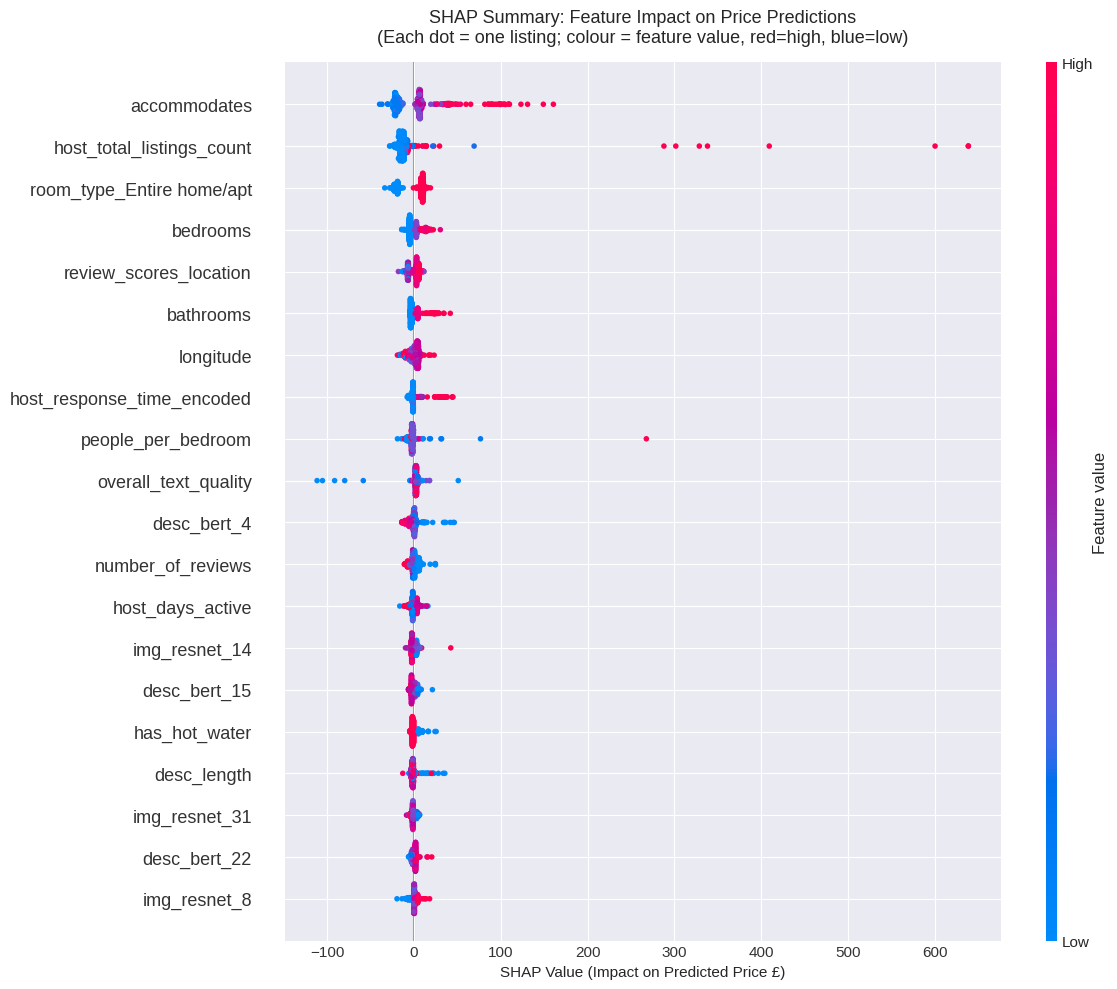

Saved: shap_summary_beeswarm.png


In [9]:
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values, X_test_sample,
    max_display=20, show=False, plot_size=None
)
plt.title(
    'SHAP Summary: Feature Impact on Price Predictions\n'
    '(Each dot = one listing; colour = feature value, red=high, blue=low)',
    fontsize=13, pad=15
)
plt.xlabel('SHAP Value (Impact on Predicted Price £)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_beeswarm.png")

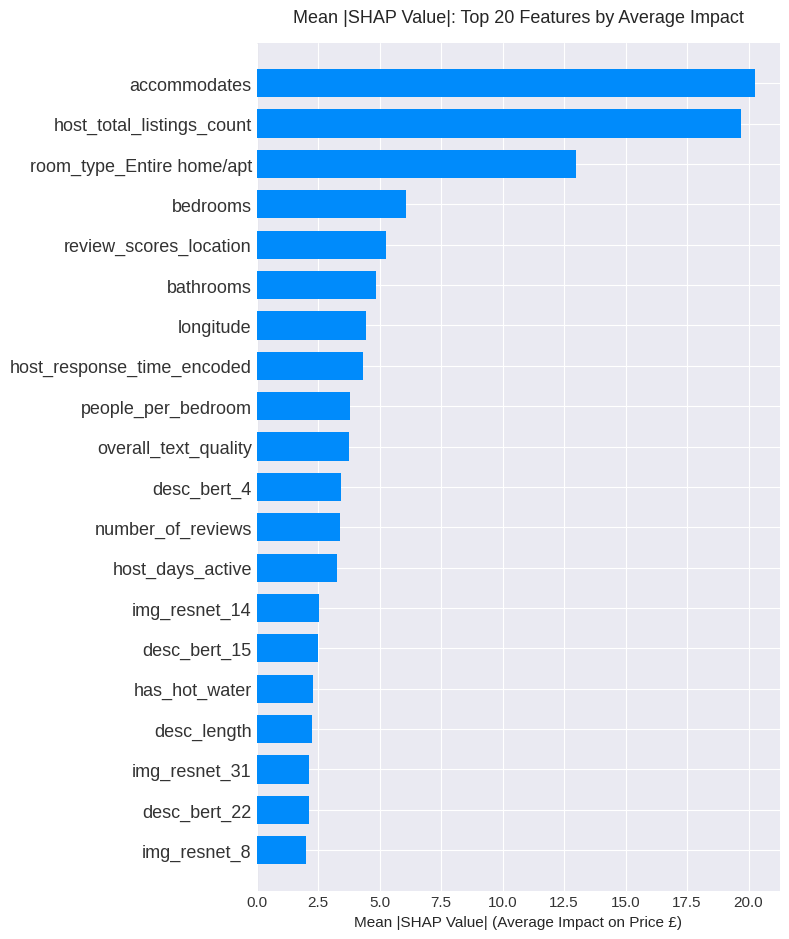

Saved: shap_summary_bar.png


In [10]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_array, X_test_sample,
    plot_type='bar', max_display=20, show=False
)
plt.title('Mean |SHAP Value|: Top 20 Features by Average Impact', fontsize=13, pad=15)
plt.xlabel('Mean |SHAP Value| (Average Impact on Price £)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_bar.png")

In [11]:
mean_shap = pd.DataFrame({
    'feature':       X_test_sample.columns,
    'mean_abs_shap': np.abs(shap_array).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("Top 20 Features by Mean |SHAP Value|:")
print("-" * 55)
for _, row in mean_shap.head(20).iterrows():
    feature_type = ""
    if row['feature'].startswith('name_bert_') or row['feature'].startswith('desc_bert_'):
        feature_type = " [BERT]"
    elif row['feature'].startswith('img_resnet_'):
        feature_type = " [ResNet50]"
    print(f"  {row['feature']:.<42} £{row['mean_abs_shap']:.2f}{feature_type}")

# Summarise modality contributions
structured_shap = mean_shap[~mean_shap['feature'].str.startswith(
    ('name_bert_', 'desc_bert_', 'img_resnet_', 'has_picture'))]['mean_abs_shap'].sum()
bert_shap   = mean_shap[mean_shap['feature'].str.startswith(
    ('name_bert_', 'desc_bert_'))]['mean_abs_shap'].sum()
resnet_shap = mean_shap[mean_shap['feature'].str.startswith(
    'img_resnet_')]['mean_abs_shap'].sum()
total_shap  = mean_shap['mean_abs_shap'].sum()

print(f"\nSHAP contribution by modality:")
print(f"  Structured features:  £{structured_shap:.2f}  ({structured_shap/total_shap*100:.1f}%)")
print(f"  DistilBERT features:  £{bert_shap:.2f}  ({bert_shap/total_shap*100:.1f}%)")
print(f"  ResNet50 features:    £{resnet_shap:.2f}  ({resnet_shap/total_shap*100:.1f}%)")
print(f"\nNote: Structured features dominate — consistent with ablation study.")

Top 20 Features by Mean |SHAP Value|:
-------------------------------------------------------
  accommodates.............................. £20.27
  host_total_listings_count................. £19.71
  room_type_Entire home/apt................. £12.99
  bedrooms.................................. £6.05
  review_scores_location.................... £5.26
  bathrooms................................. £4.86
  longitude................................. £4.46
  host_response_time_encoded................ £4.32
  people_per_bedroom........................ £3.78
  overall_text_quality...................... £3.73
  desc_bert_4............................... £3.45 [BERT]
  number_of_reviews......................... £3.38
  host_days_active.......................... £3.28
  img_resnet_14............................. £2.52 [ResNet50]
  desc_bert_15.............................. £2.49 [BERT]
  has_hot_water............................. £2.30
  desc_length............................... £2.26
  img_resne

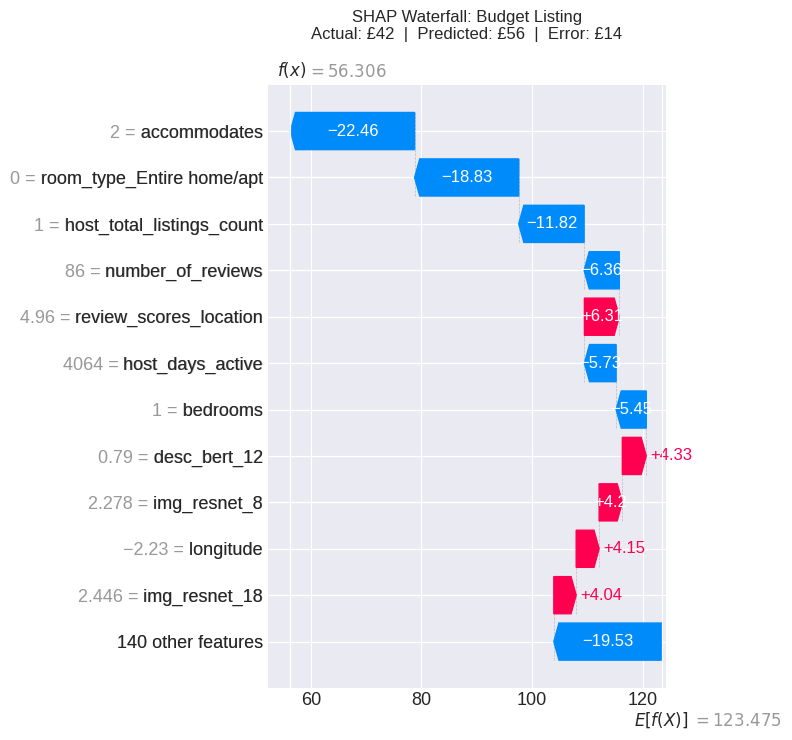

Saved: shap_waterfall_budget_listing.png  (Actual £42  Predicted £56)


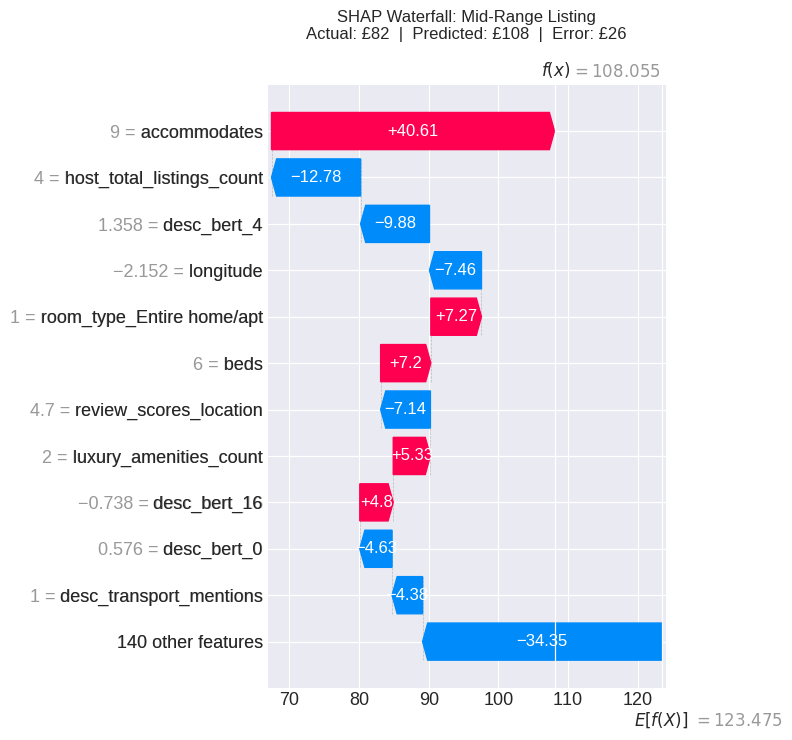

Saved: shap_waterfall_mid-range_listing.png  (Actual £82  Predicted £108)


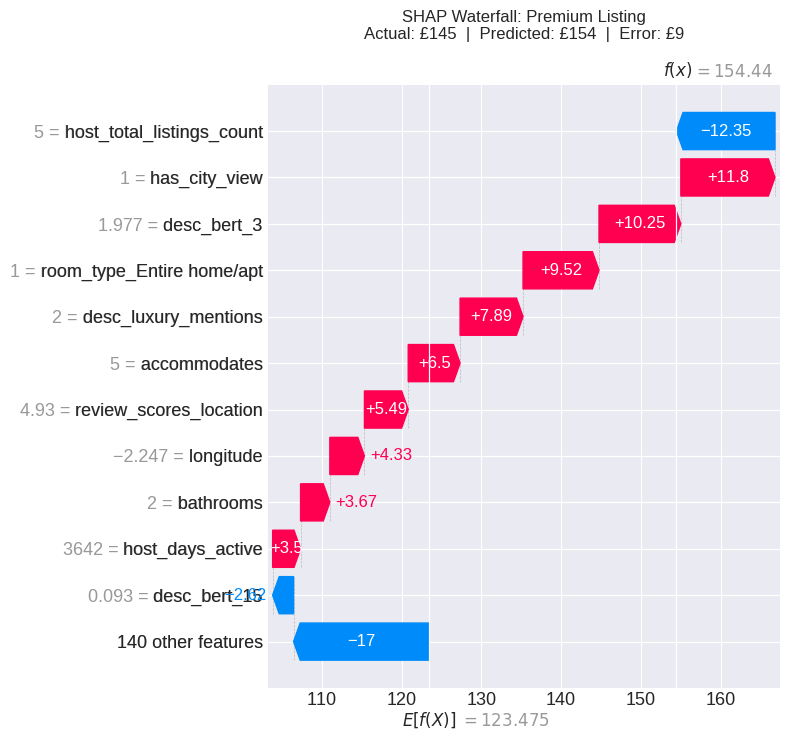

Saved: shap_waterfall_premium_listing.png  (Actual £145  Predicted £154)


In [12]:
pred_prices = model.predict(X_test_sample)
pred_series = pd.Series(pred_prices, index=X_test_sample.index)

listing_examples = {
    'Budget Listing':    (pred_series - pred_series.quantile(0.20)).abs().idxmin(),
    'Mid-Range Listing': (pred_series - pred_series.quantile(0.50)).abs().idxmin(),
    'Premium Listing':   (pred_series - pred_series.quantile(0.80)).abs().idxmin(),
}

for label, idx in listing_examples.items():
    pos       = X_test_sample.index.get_loc(idx)
    actual    = y_test_sample.loc[idx]
    predicted = pred_series.loc[idx]

    plt.figure(figsize=(14, 6))
    shap.waterfall_plot(shap_values[pos], max_display=12, show=False)
    plt.title(
        f'SHAP Waterfall: {label}\n'
        f'Actual: £{actual:.0f}  |  Predicted: £{predicted:.0f}  |  '
        f'Error: £{abs(actual-predicted):.0f}',
        fontsize=12, pad=15
    )
    plt.tight_layout()
    fname = f"shap_waterfall_{label.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}  (Actual £{actual:.0f}  Predicted £{predicted:.0f})")


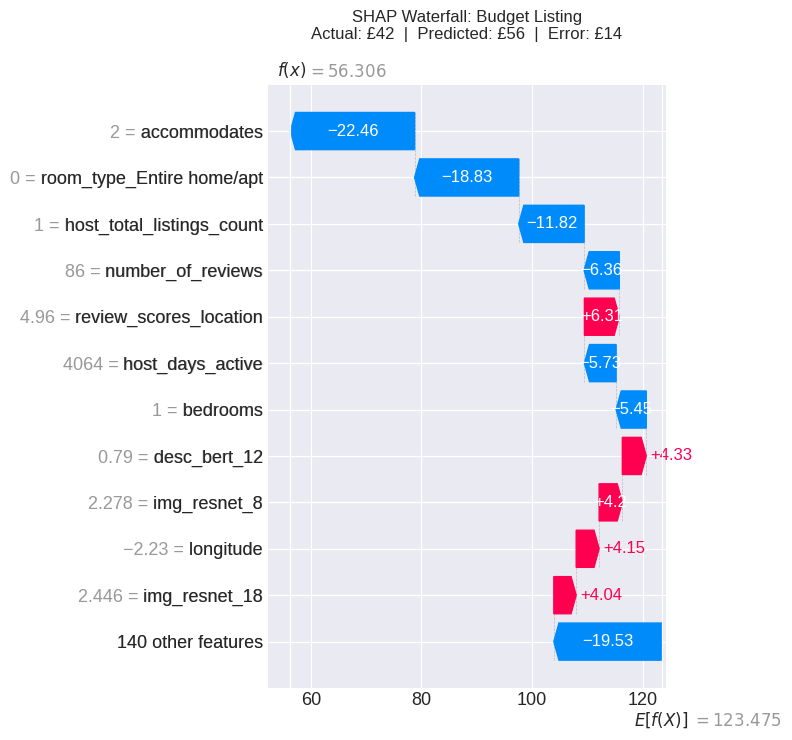

Saved: shap_waterfall_budget_listing.png  (Actual £42  Predicted £56)


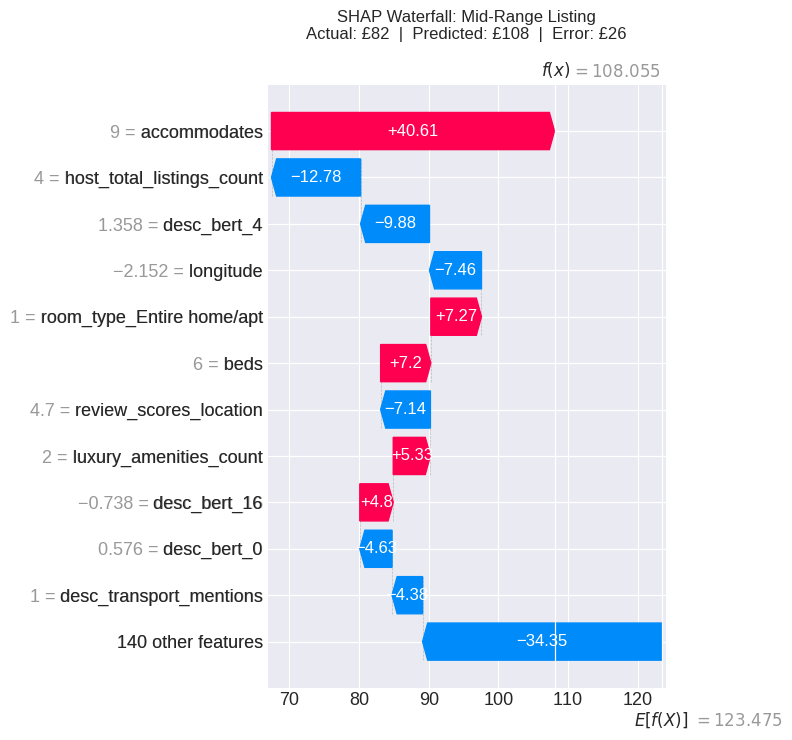

Saved: shap_waterfall_mid-range_listing.png  (Actual £82  Predicted £108)


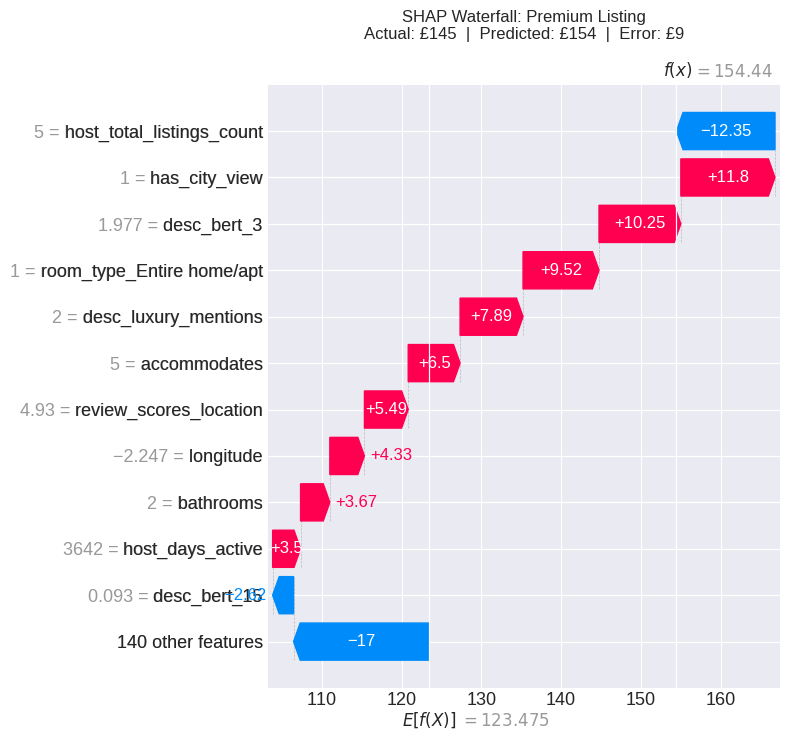

Saved: shap_waterfall_premium_listing.png  (Actual £145  Predicted £154)


In [13]:
pred_prices = model.predict(X_test_sample)
pred_series = pd.Series(pred_prices, index=X_test_sample.index)

listing_examples = {
    'Budget Listing':    (pred_series - pred_series.quantile(0.20)).abs().idxmin(),
    'Mid-Range Listing': (pred_series - pred_series.quantile(0.50)).abs().idxmin(),
    'Premium Listing':   (pred_series - pred_series.quantile(0.80)).abs().idxmin(),
}

for label, idx in listing_examples.items():
    pos       = X_test_sample.index.get_loc(idx)
    actual    = y_test_sample.loc[idx]
    predicted = pred_series.loc[idx]

    plt.figure(figsize=(14, 6))
    shap.waterfall_plot(shap_values[pos], max_display=12, show=False)
    plt.title(
        f'SHAP Waterfall: {label}\n'
        f'Actual: £{actual:.0f}  |  Predicted: £{predicted:.0f}  |  '
        f'Error: £{abs(actual-predicted):.0f}',
        fontsize=12, pad=15
    )
    plt.tight_layout()
    fname = f"shap_waterfall_{label.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}  (Actual £{actual:.0f}  Predicted £{predicted:.0f})")


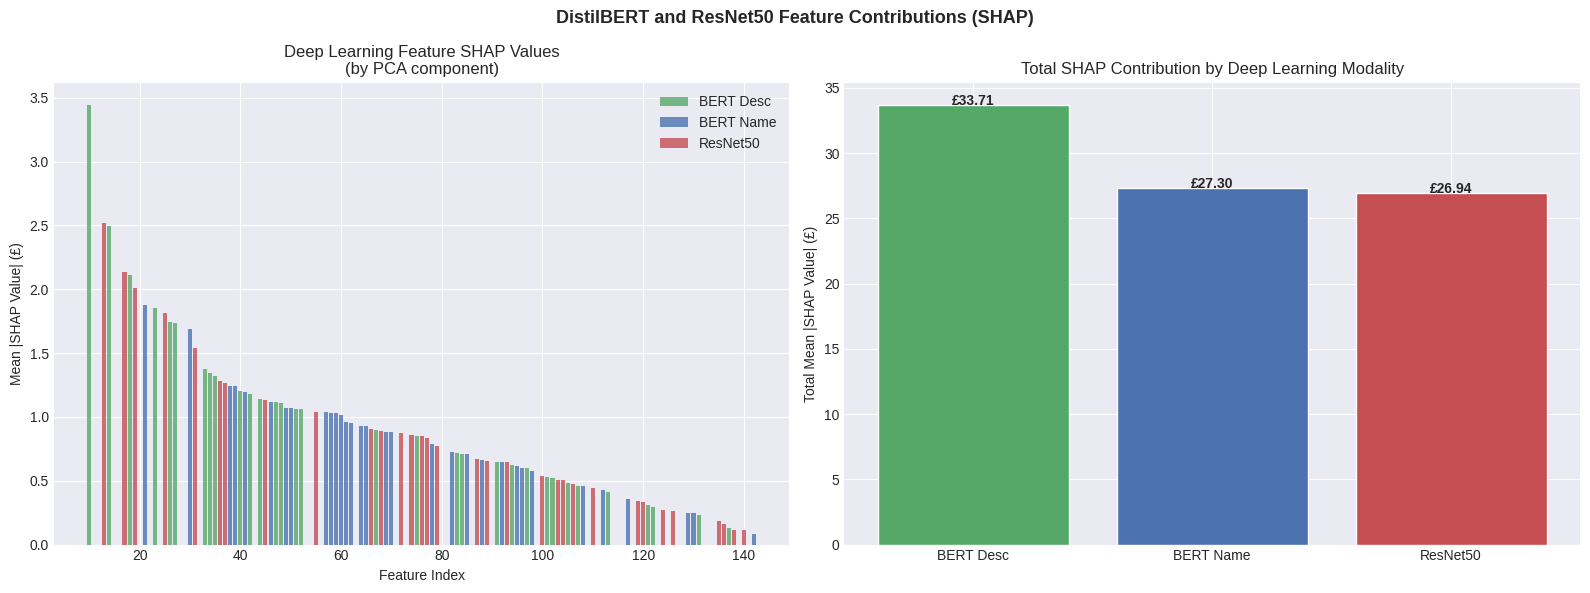

Saved: shap_dl_features.png

DL modality SHAP totals (all in £ average impact per prediction):
modality
BERT Desc   33.711
BERT Name   27.302
ResNet50    26.942


In [14]:
dl_shap_summary = mean_shap[mean_shap['feature'].str.startswith(
    ('name_bert_', 'desc_bert_', 'img_resnet_'))].copy()
dl_shap_summary['modality'] = np.where(
    dl_shap_summary['feature'].str.startswith('img_resnet_'), 'ResNet50',
    np.where(dl_shap_summary['feature'].str.startswith('name_bert_'),
             'BERT Name', 'BERT Desc')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Per-component SHAP by modality
colors_dl = {'BERT Name': '#4C72B0', 'BERT Desc': '#55A868', 'ResNet50': '#C44E52'}
for modality, group in dl_shap_summary.groupby('modality'):
    axes[0].bar(group.index, group['mean_abs_shap'],
                label=modality, color=colors_dl[modality], alpha=0.8)
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Mean |SHAP Value| (£)')
axes[0].set_title('Deep Learning Feature SHAP Values\n(by PCA component)')
axes[0].legend()

# Aggregated by modality
mod_totals = dl_shap_summary.groupby('modality')['mean_abs_shap'].sum()
axes[1].bar(mod_totals.index, mod_totals.values,
            color=[colors_dl[m] for m in mod_totals.index], edgecolor='white')
axes[1].set_ylabel('Total Mean |SHAP Value| (£)')
axes[1].set_title('Total SHAP Contribution by Deep Learning Modality')
for i, v in enumerate(mod_totals.values):
    axes[1].text(i, v + 0.01, f'£{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('DistilBERT and ResNet50 Feature Contributions (SHAP)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dl_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dl_features.png")
print(f"\nDL modality SHAP totals (all in £ average impact per prediction):")
print(mod_totals.to_string())


# Fairness Audit

In [15]:
audit_df = df.loc[X_test.index].copy()
audit_df['predicted'] = y_test_pred
audit_df['actual']    = y_test.values
audit_df['residual']  = audit_df['actual'] - audit_df['predicted']
audit_df['abs_error'] = audit_df['residual'].abs()
audit_df['pct_error'] = (audit_df['abs_error'] / audit_df['actual'].clip(lower=1)) * 100

print(f"Fairness audit dataset: {len(audit_df):,} test listings")
print(f"\nOverall test performance:")
print(f"  MAE:  £{audit_df['abs_error'].mean():.2f}")
print(f"  RMSE: £{np.sqrt(mean_squared_error(audit_df['actual'], audit_df['predicted'])):.2f}")
print(f"  R²:   {r2_score(audit_df['actual'], audit_df['predicted']):.4f}")
print(f"  Mean residual: £{audit_df['residual'].mean():.2f} (0 = unbiased)")


def group_metrics(group_df):
    """Compute fairness metrics for a subgroup."""
    if len(group_df) < 10:
        return None
    actual    = group_df['actual']
    predicted = group_df['predicted']
    mae       = mean_absolute_error(actual, predicted)
    rmse      = np.sqrt(mean_squared_error(actual, predicted))
    r2        = r2_score(actual, predicted)
    return {
        'n':                   len(group_df),
        'median_price':        actual.median(),
        'mae':                 mae,
        'rmse':                rmse,
        'r2':                  r2,
        'mean_residual':       group_df['residual'].mean(),
        'mae_pct_median':      (mae / actual.median()) * 100
    }

Fairness audit dataset: 1,313 test listings

Overall test performance:
  MAE:  £40.94
  RMSE: £84.73
  R²:   0.5015
  Mean residual: £0.39 (0 = unbiased)



Fairness Dimension 1 — Room Type:
--------------------------------------------------------------------------------
Room Type                          N   Med £     MAE    RMSE      R²     Bias
--------------------------------------------------------------------------------
  Private room                   424     42   27.75   65.78   0.260      -£3
  Entire home/apt                880    108   47.45   92.83   0.472      +£2

80% Disparate Impact Rule (Room Type):
  Reference MAE (best group): £27.75
  80% threshold:              £34.69  (groups above this fail)
  Private room                   MAE ratio: 1.00  ✅ PASS
  Entire home/apt                MAE ratio: 0.58  ❌ FAIL


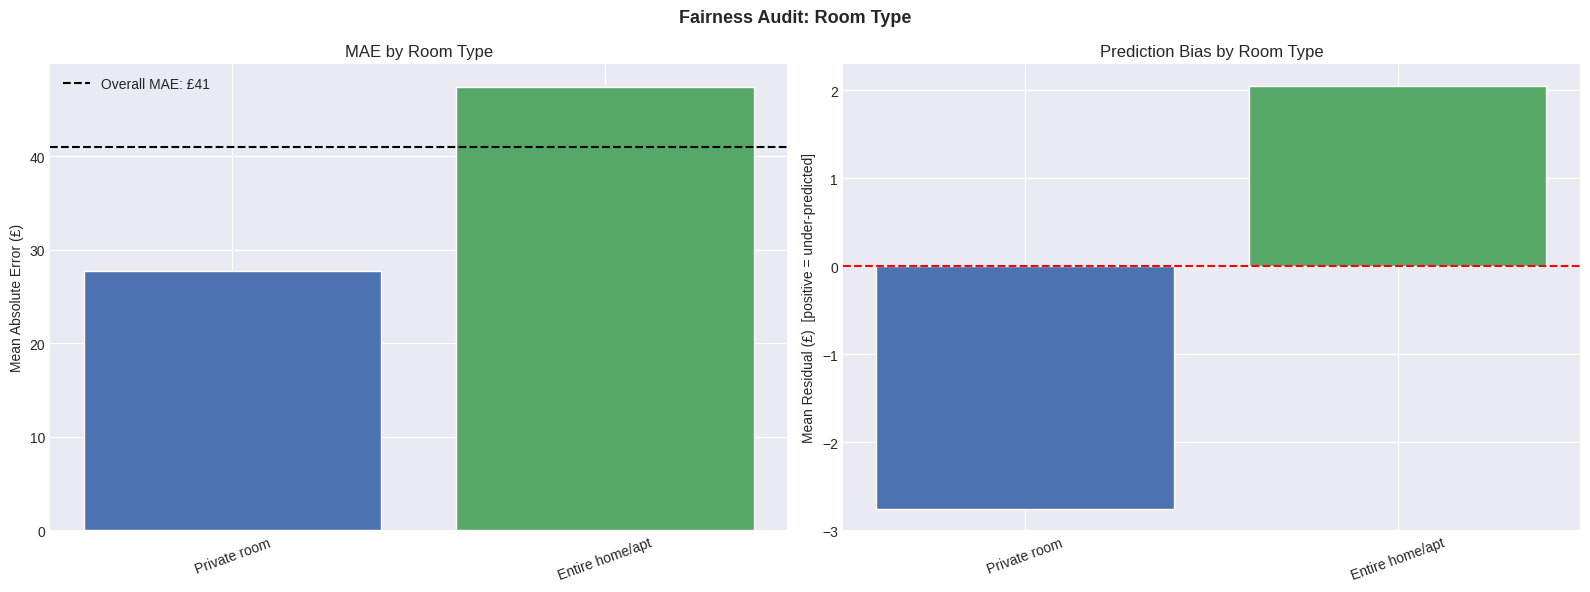

Saved: fairness_room_type.png


In [16]:
room_cols = [c for c in audit_df.columns if c.startswith('room_type_')]

def get_room_type(row):
    for col in room_cols:
        if row[col] == 1 or row[col] == True:
            return col.replace('room_type_', '')
    return 'Other'

audit_df['room_type'] = audit_df.apply(get_room_type, axis=1)

room_results = []
for rt, grp in audit_df.groupby('room_type'):
    m = group_metrics(grp)
    if m:
        m['room_type'] = rt
        room_results.append(m)

room_df = pd.DataFrame(room_results).sort_values('mae')

print("\nFairness Dimension 1 — Room Type:")
print("-" * 80)
print(f"{'Room Type':<30} {'N':>5} {'Med £':>7} {'MAE':>7} {'RMSE':>7} {'R²':>7} {'Bias':>8}")
print("-" * 80)
for _, r in room_df.iterrows():
    bias = f"+£{r['mean_residual']:.0f}" if r['mean_residual'] > 0 else f"-£{abs(r['mean_residual']):.0f}"
    print(f"  {r['room_type']:<28} {r['n']:>5} {r['median_price']:>6.0f} "
          f"{r['mae']:>7.2f} {r['rmse']:>7.2f} {r['r2']:>7.3f} {bias:>8}")

# 80% Disparate Impact Rule for Room Type
best_mae_room = room_df['mae'].min()
print(f"\n80% Disparate Impact Rule (Room Type):")
print(f"  Reference MAE (best group): £{best_mae_room:.2f}")
print(f"  80% threshold:              £{best_mae_room * 1.25:.2f}  (groups above this fail)")
for _, r in room_df.iterrows():
    ratio   = best_mae_room / r['mae']
    passing = "✅ PASS" if ratio >= 0.80 else "❌ FAIL"
    print(f"  {r['room_type']:<30} MAE ratio: {ratio:.2f}  {passing}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_rt = ['#4C72B0', '#55A868', '#C44E52', '#8172B2'][:len(room_df)]

axes[0].bar(room_df['room_type'], room_df['mae'], color=colors_rt, edgecolor='white')
axes[0].axhline(audit_df['abs_error'].mean(), color='black', linestyle='--',
                linewidth=1.5, label=f"Overall MAE: £{audit_df['abs_error'].mean():.0f}")
axes[0].set_ylabel('Mean Absolute Error (£)')
axes[0].set_title('MAE by Room Type')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

axes[1].bar(room_df['room_type'], room_df['mean_residual'], color=colors_rt, edgecolor='white')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('Mean Residual (£)  [positive = under-predicted]')
axes[1].set_title('Prediction Bias by Room Type')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Fairness Audit: Room Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fairness_room_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fairness_room_type.png")



Fairness Dimension 2 — Price Segment:
-------------------------------------------------------------------------------------
Segment                       N   Med £     MAE    MAE%    RMSE      R²
-------------------------------------------------------------------------------------
  Budget (<£55)             341     38   23.85   62.8%   43.67 -21.767
  Mid-Range (£55–90)        328     74   30.43   41.1%   42.30 -16.408
  Premium (£90–129)         318    107   27.98   26.2%   40.06 -13.568
  Luxury (£129+)            326    172   82.01   47.8%  153.48   0.308

Note: Negative R² within a narrow price band is expected — it indicates
the model's variance exceeds the within-band variance, not model failure.
MAE% (relative to median) is a fairer cross-segment comparison.


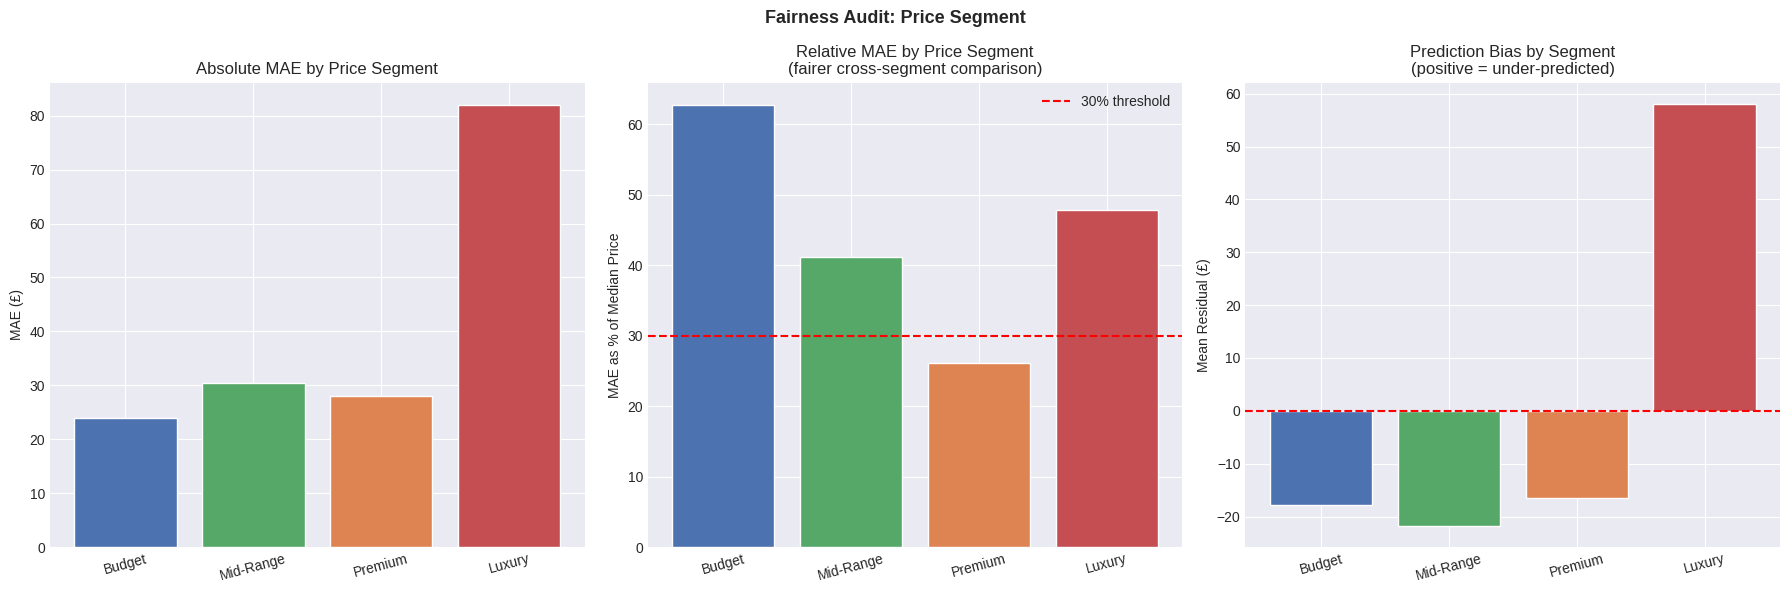

Saved: fairness_price_segment.png


In [17]:
audit_df['price_segment'] = pd.cut(
    audit_df['actual'],
    bins=[0, 55, 90, 129, 10000],
    labels=['Budget (<£55)', 'Mid-Range (£55–90)', 'Premium (£90–129)', 'Luxury (£129+)']
)

seg_results = []
seg_order   = ['Budget (<£55)', 'Mid-Range (£55–90)', 'Premium (£90–129)', 'Luxury (£129+)']
for seg in seg_order:
    grp = audit_df[audit_df['price_segment'] == seg]
    m   = group_metrics(grp)
    if m:
        m['segment'] = seg
        seg_results.append(m)

seg_df = pd.DataFrame(seg_results)

print("\nFairness Dimension 2 — Price Segment:")
print("-" * 85)
print(f"{'Segment':<25} {'N':>5} {'Med £':>7} {'MAE':>7} {'MAE%':>7} {'RMSE':>7} {'R²':>7}")
print("-" * 85)
for _, r in seg_df.iterrows():
    print(f"  {r['segment']:<23} {r['n']:>5} {r['median_price']:>6.0f} "
          f"{r['mae']:>7.2f} {r['mae_pct_median']:>6.1f}% {r['rmse']:>7.2f} {r['r2']:>7.3f}")

print("\nNote: Negative R² within a narrow price band is expected — it indicates")
print("the model's variance exceeds the within-band variance, not model failure.")
print("MAE% (relative to median) is a fairer cross-segment comparison.")

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
seg_colours = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

axes[0].bar(range(len(seg_df)), seg_df['mae'],
            color=seg_colours, edgecolor='white')
axes[0].set_xticks(range(len(seg_df)))
axes[0].set_xticklabels([s.split(' ')[0] for s in seg_df['segment']], rotation=15)
axes[0].set_ylabel('MAE (£)')
axes[0].set_title('Absolute MAE by Price Segment')

axes[1].bar(range(len(seg_df)), seg_df['mae_pct_median'],
            color=seg_colours, edgecolor='white')
axes[1].set_xticks(range(len(seg_df)))
axes[1].set_xticklabels([s.split(' ')[0] for s in seg_df['segment']], rotation=15)
axes[1].set_ylabel('MAE as % of Median Price')
axes[1].set_title('Relative MAE by Price Segment\n(fairer cross-segment comparison)')
axes[1].axhline(30, color='red', linestyle='--', linewidth=1.5,
                label='30% threshold')
axes[1].legend()

axes[2].bar(range(len(seg_df)), seg_df['mean_residual'],
            color=seg_colours, edgecolor='white')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xticks(range(len(seg_df)))
axes[2].set_xticklabels([s.split(' ')[0] for s in seg_df['segment']], rotation=15)
axes[2].set_ylabel('Mean Residual (£)')
axes[2].set_title('Prediction Bias by Segment\n(positive = under-predicted)')

plt.suptitle('Fairness Audit: Price Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fairness_price_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fairness_price_segment.png")

In [18]:
superhost_results = []
for status, grp in audit_df.groupby('host_is_superhost'):
    m = group_metrics(grp)
    if m:
        m['host_type'] = 'Superhost' if status else 'Regular Host'
        superhost_results.append(m)

sh_df = pd.DataFrame(superhost_results)

print("\nFairness Dimension 3 — Superhost Status:")
print("-" * 75)
print(f"{'Host Type':<18} {'N':>5} {'Med £':>7} {'MAE':>7} {'RMSE':>7} {'R²':>7} {'Bias':>8}")
print("-" * 75)
for _, r in sh_df.iterrows():
    bias = f"+£{r['mean_residual']:.0f}" if r['mean_residual'] > 0 else f"-£{abs(r['mean_residual']):.0f}"
    print(f"  {r['host_type']:<16} {r['n']:>5} {r['median_price']:>6.0f} "
          f"{r['mae']:>7.2f} {r['rmse']:>7.2f} {r['r2']:>7.3f} {bias:>8}")

# Statistical test
sh_errors  = audit_df[audit_df['host_is_superhost'] == True]['abs_error']
reg_errors = audit_df[audit_df['host_is_superhost'] == False]['abs_error']
u_stat, p_val = stats.mannwhitneyu(sh_errors, reg_errors, alternative='two-sided')
print(f"\nMann-Whitney U test (error difference, superhost vs regular):")
print(f"  U = {u_stat:.2f},  p = {p_val:.4f}")
print(f"  {'Significant (p < 0.05)' if p_val < 0.05 else 'Not significant (p ≥ 0.05)'}")

# 80% Disparate Impact Rule
best_mae_sh = sh_df['mae'].min()
print(f"\n80% Disparate Impact Rule (Superhost):")
for _, r in sh_df.iterrows():
    ratio   = best_mae_sh / r['mae']
    passing = "✅ PASS" if ratio >= 0.80 else "❌ FAIL"
    print(f"  {r['host_type']:<18} MAE ratio: {ratio:.2f}  {passing}")


Fairness Dimension 3 — Superhost Status:
---------------------------------------------------------------------------
Host Type              N   Med £     MAE    RMSE      R²     Bias
---------------------------------------------------------------------------
  Regular Host       964     89   39.69   79.11   0.549      -£3
  Superhost          349     92   44.38   98.60   0.386     +£11

Mann-Whitney U test (error difference, superhost vs regular):
  U = 163714.00,  p = 0.4581
  Not significant (p ≥ 0.05)

80% Disparate Impact Rule (Superhost):
  Regular Host       MAE ratio: 1.00  ✅ PASS
  Superhost          MAE ratio: 0.89  ✅ PASS



Fairness Dimension 4 — Geographic Area (Latitude Tertiles):
--------------------------------------------------------------------------------
Area                   N   Med £     MAE    RMSE      R²     Bias
--------------------------------------------------------------------------------
  North GM           437     85   38.85   73.13   0.550      -£5
  Central GM         439    105   40.57   86.10   0.503      +£8
  South GM           437     75   43.39   93.68   0.452      -£2

80% Disparate Impact Rule (Geographic Area):
  North GM           MAE ratio: 1.00  ✅ PASS
  Central GM         MAE ratio: 0.96  ✅ PASS
  South GM           MAE ratio: 0.90  ✅ PASS


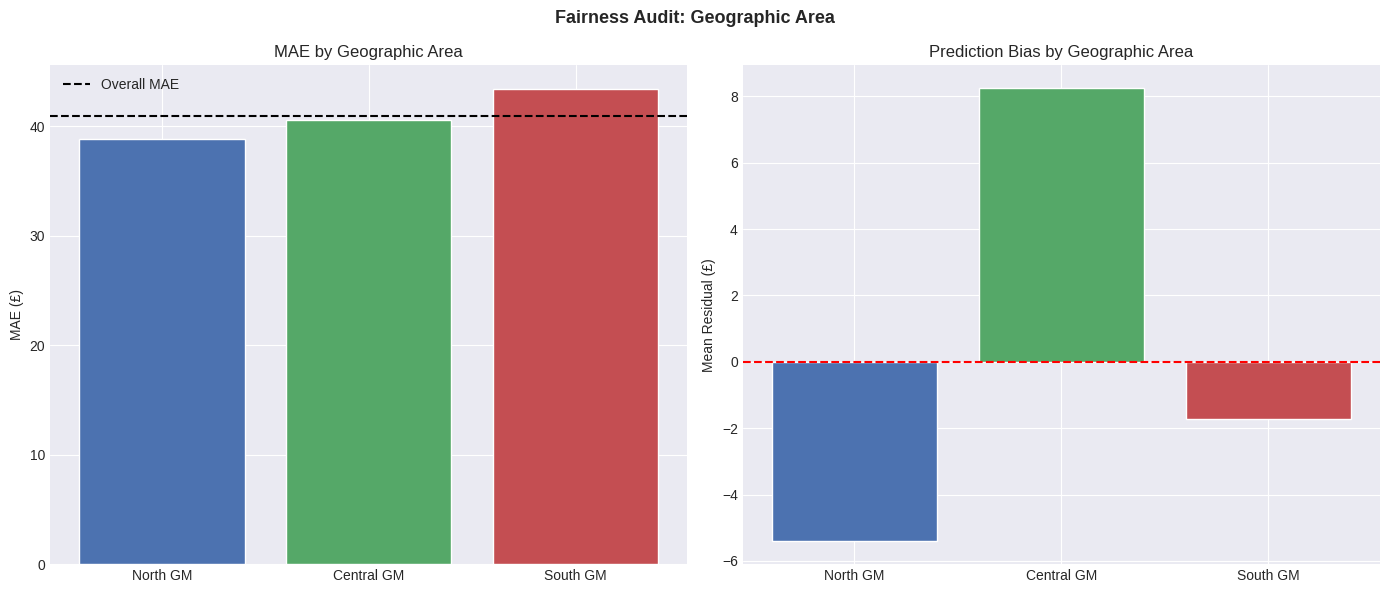

Saved: fairness_geographic.png


In [19]:
lat_q = audit_df['latitude'].quantile([0.333, 0.667])
def assign_area(lat):
    if lat <= lat_q[0.333]:
        return 'South GM'
    elif lat <= lat_q[0.667]:
        return 'Central GM'
    else:
        return 'North GM'

audit_df['geo_area'] = audit_df['latitude'].apply(assign_area)

geo_results = []
for area, grp in audit_df.groupby('geo_area'):
    m = group_metrics(grp)
    if m:
        m['area'] = area
        geo_results.append(m)

geo_df = pd.DataFrame(geo_results).sort_values('mae')

print("\nFairness Dimension 4 — Geographic Area (Latitude Tertiles):")
print("-" * 80)
print(f"{'Area':<18} {'N':>5} {'Med £':>7} {'MAE':>7} {'RMSE':>7} {'R²':>7} {'Bias':>8}")
print("-" * 80)
for _, r in geo_df.iterrows():
    bias = f"+£{r['mean_residual']:.0f}" if r['mean_residual'] > 0 else f"-£{abs(r['mean_residual']):.0f}"
    print(f"  {r['area']:<16} {r['n']:>5} {r['median_price']:>6.0f} "
          f"{r['mae']:>7.2f} {r['rmse']:>7.2f} {r['r2']:>7.3f} {bias:>8}")

# 80% Disparate Impact Rule
best_mae_geo = geo_df['mae'].min()
print(f"\n80% Disparate Impact Rule (Geographic Area):")
for _, r in geo_df.iterrows():
    ratio   = best_mae_geo / r['mae']
    passing = "✅ PASS" if ratio >= 0.80 else "❌ FAIL"
    print(f"  {r['area']:<18} MAE ratio: {ratio:.2f}  {passing}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_geo = ['#4C72B0', '#55A868', '#C44E52']

axes[0].bar(geo_df['area'], geo_df['mae'], color=colors_geo, edgecolor='white')
axes[0].axhline(audit_df['abs_error'].mean(), color='black', linestyle='--',
                linewidth=1.5, label='Overall MAE')
axes[0].set_ylabel('MAE (£)')
axes[0].set_title('MAE by Geographic Area')
axes[0].legend()

axes[1].bar(geo_df['area'], geo_df['mean_residual'], color=colors_geo, edgecolor='white')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('Mean Residual (£)')
axes[1].set_title('Prediction Bias by Geographic Area')

plt.suptitle('Fairness Audit: Geographic Area', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fairness_geographic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fairness_geographic.png")


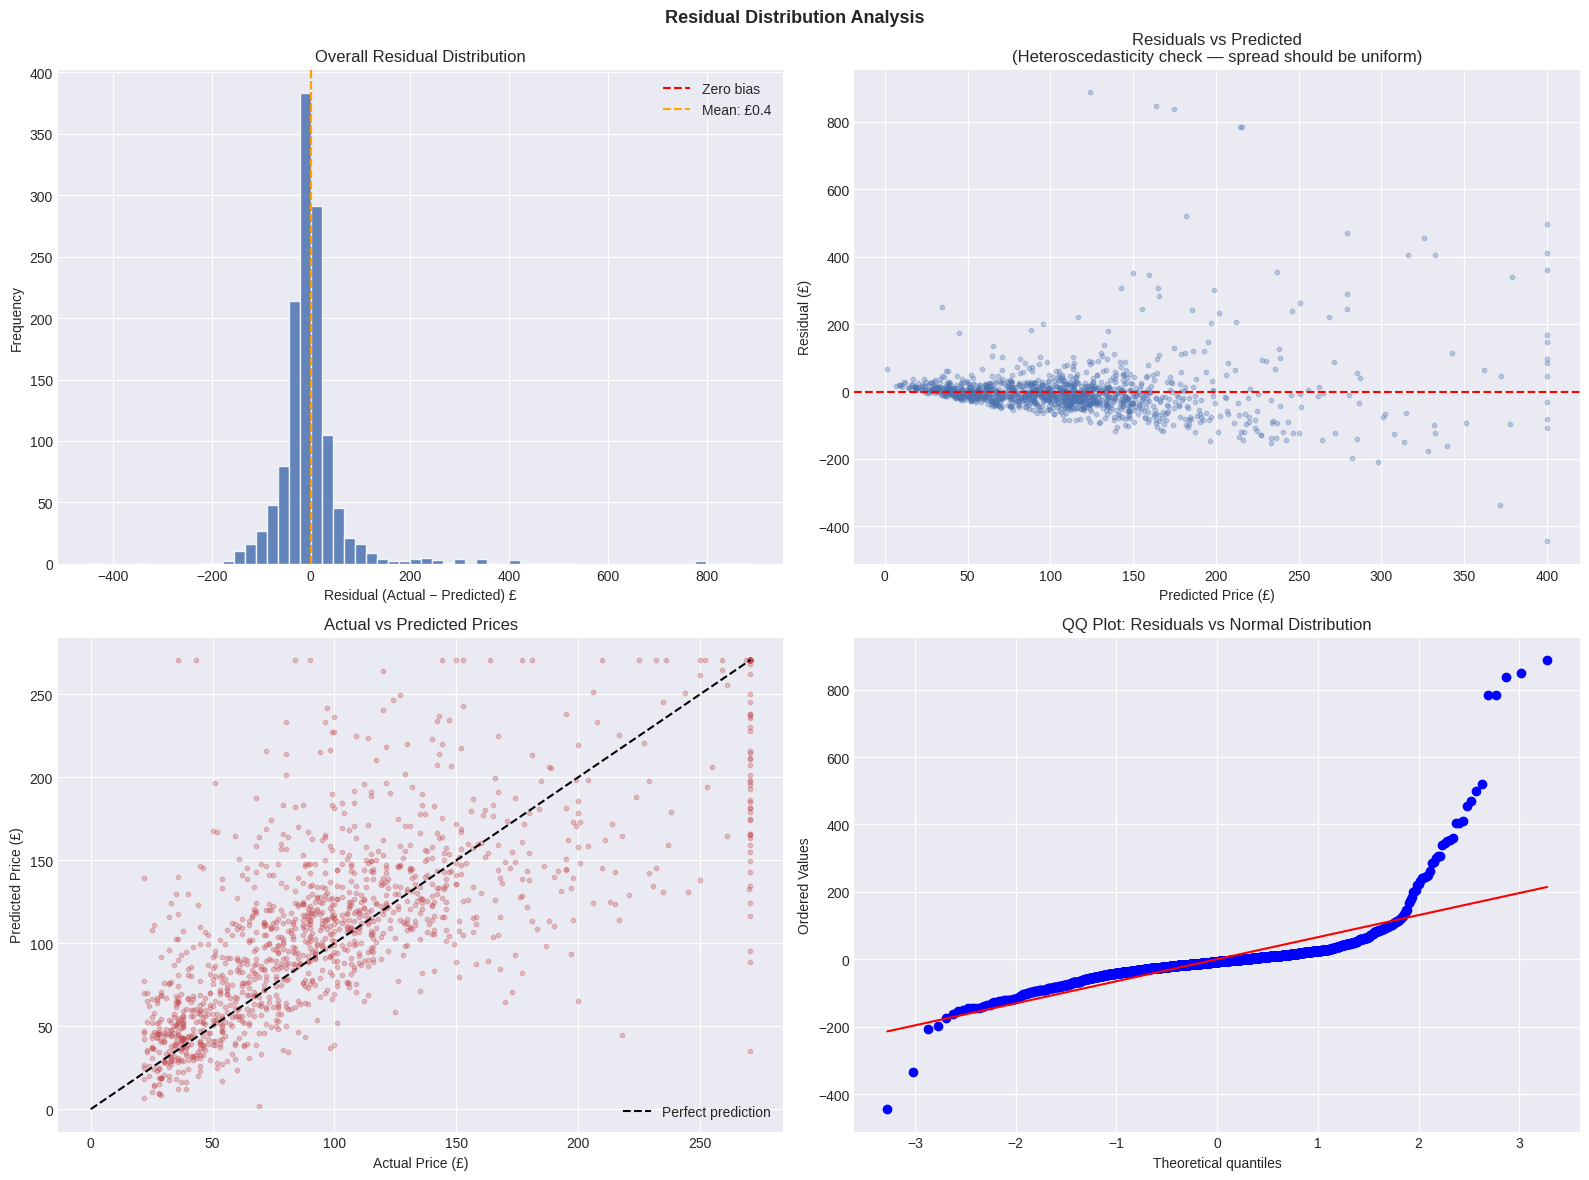

Saved: fairness_residuals.png

Residual statistics:
  Mean:     £0.39
  Std:      £84.76
  Skewness: 4.793
  Kurtosis: 40.377


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall residual distribution
axes[0, 0].hist(audit_df['residual'], bins=60, color='#4C72B0',
                edgecolor='white', alpha=0.85)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero bias')
axes[0, 0].axvline(audit_df['residual'].mean(), color='orange', linestyle='--',
                   linewidth=1.5,
                   label=f"Mean: £{audit_df['residual'].mean():.1f}")
axes[0, 0].set_xlabel('Residual (Actual − Predicted) £')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall Residual Distribution')
axes[0, 0].legend()

# Residuals vs predicted (heteroscedasticity check)
axes[0, 1].scatter(np.clip(audit_df['predicted'], 0, 400),
                   audit_df['residual'],
                   alpha=0.3, s=10, color='#4C72B0')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_xlabel('Predicted Price (£)')
axes[0, 1].set_ylabel('Residual (£)')
axes[0, 1].set_title('Residuals vs Predicted\n(Heteroscedasticity check — spread should be uniform)')

# Actual vs predicted
p95 = max(audit_df['actual'].quantile(0.95), audit_df['predicted'].quantile(0.95))
axes[1, 0].scatter(np.clip(audit_df['actual'], 0, p95),
                   np.clip(audit_df['predicted'], 0, p95),
                   alpha=0.3, s=10, color='#C44E52')
axes[1, 0].plot([0, p95], [0, p95], 'k--', linewidth=1.5, label='Perfect prediction')
axes[1, 0].set_xlabel('Actual Price (£)')
axes[1, 0].set_ylabel('Predicted Price (£)')
axes[1, 0].set_title('Actual vs Predicted Prices')
axes[1, 0].legend()

# QQ plot of residuals
stats.probplot(audit_df['residual'], dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ Plot: Residuals vs Normal Distribution')

plt.suptitle('Residual Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fairness_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fairness_residuals.png")

print(f"\nResidual statistics:")
print(f"  Mean:     £{audit_df['residual'].mean():.2f}")
print(f"  Std:      £{audit_df['residual'].std():.2f}")
print(f"  Skewness: {audit_df['residual'].skew():.3f}")
print(f"  Kurtosis: {audit_df['residual'].kurtosis():.3f}")

In [21]:
print("=" * 65)
print("80% DISPARATE IMPACT RULE — FULL AUDIT SUMMARY")
print("=" * 65)
print("""
The 80% Disparate Impact Rule (Uniform Guidelines on Employee Selection,
1978) states that a selection procedure has adverse impact if the benefit
rate for a protected group is less than 80% of the rate for the most
favoured group. Adapted here for regression: a subgroup fails if its
MAE ratio (best MAE / group MAE) falls below 0.80, meaning the group
experiences more than 25% worse prediction accuracy than the best group.
""")

all_dimensions = [
    ('Room Type',      room_df,  'room_type'),
    ('Price Segment',  seg_df,   'segment'),
    ('Superhost',      sh_df,    'host_type'),
    ('Geographic Area',geo_df,   'area'),
]

for dim_name, dim_df, label_col in all_dimensions:
    best = dim_df['mae'].min()
    print(f"\n{dim_name}  (best MAE = £{best:.2f}):")
    for _, r in dim_df.iterrows():
        ratio   = best / r['mae']
        passing = "✅ PASS" if ratio >= 0.80 else "❌ FAIL"
        print(f"  {str(r[label_col]):<32} ratio={ratio:.2f}  MAE=£{r['mae']:.0f}  {passing}")


80% DISPARATE IMPACT RULE — FULL AUDIT SUMMARY

The 80% Disparate Impact Rule (Uniform Guidelines on Employee Selection,
1978) states that a selection procedure has adverse impact if the benefit
rate for a protected group is less than 80% of the rate for the most
favoured group. Adapted here for regression: a subgroup fails if its
MAE ratio (best MAE / group MAE) falls below 0.80, meaning the group
experiences more than 25% worse prediction accuracy than the best group.


Room Type  (best MAE = £27.75):
  Private room                     ratio=1.00  MAE=£28  ✅ PASS
  Entire home/apt                  ratio=0.58  MAE=£47  ❌ FAIL

Price Segment  (best MAE = £23.85):
  Budget (<£55)                    ratio=1.00  MAE=£24  ✅ PASS
  Mid-Range (£55–90)               ratio=0.78  MAE=£30  ❌ FAIL
  Premium (£90–129)                ratio=0.85  MAE=£28  ✅ PASS
  Luxury (£129+)                   ratio=0.29  MAE=£82  ❌ FAIL

Superhost  (best MAE = £39.69):
  Regular Host                     ratio=1.

In [22]:
print("=" * 60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# Room type
room_groups = [grp['abs_error'].values
               for _, grp in audit_df.groupby('room_type') if len(grp) >= 10]
if len(room_groups) >= 2:
    h, p = stats.kruskal(*room_groups)
    print(f"\n1. Kruskal-Wallis — Error across Room Types:")
    print(f"   H = {h:.3f},  p = {p:.4f}  "
          f"{'(significant)' if p < 0.05 else '(not significant)'}")

# Price segment
seg_groups = [grp['abs_error'].values
              for _, grp in audit_df.groupby('price_segment', observed=True)
              if len(grp) >= 10]
if len(seg_groups) >= 2:
    h2, p2 = stats.kruskal(*seg_groups)
    print(f"\n2. Kruskal-Wallis — Error across Price Segments:")
    print(f"   H = {h2:.3f},  p = {p2:.4f}  "
          f"{'(significant)' if p2 < 0.05 else '(not significant)'}")
    print(f"   Note: Significance expected — luxury listings are structurally harder to predict.")

# Superhost
print(f"\n3. Mann-Whitney U — Superhost vs Regular Host:")
print(f"   U = {u_stat:.2f},  p = {p_val:.4f}  "
      f"{'(significant)' if p_val < 0.05 else '(not significant)'}")

# Geographic area
geo_groups = [grp['abs_error'].values
              for _, grp in audit_df.groupby('geo_area') if len(grp) >= 10]
if len(geo_groups) >= 2:
    h3, p3 = stats.kruskal(*geo_groups)
    print(f"\n4. Kruskal-Wallis — Error across Geographic Areas:")
    print(f"   H = {h3:.3f},  p = {p3:.4f}  "
          f"{'(significant)' if p3 < 0.05 else '(not significant)'}")

STATISTICAL SIGNIFICANCE TESTS

1. Kruskal-Wallis — Error across Room Types:
   H = 62.199,  p = 0.0000  (significant)

2. Kruskal-Wallis — Error across Price Segments:
   H = 119.765,  p = 0.0000  (significant)
   Note: Significance expected — luxury listings are structurally harder to predict.

3. Mann-Whitney U — Superhost vs Regular Host:
   U = 163714.00,  p = 0.4581  (not significant)

4. Kruskal-Wallis — Error across Geographic Areas:
   H = 0.195,  p = 0.9072  (not significant)


In [23]:
print("=" * 65)
print("SHAP AND FAIRNESS AUDIT — FULL SUMMARY")
print("=" * 65)

print("\nSHAP ANALYSIS:")
print(f"  Base prediction value: £{expected_value:.2f}")
print(f"  Top feature: {mean_shap.iloc[0]['feature']}  "
      f"(avg impact £{mean_shap.iloc[0]['mean_abs_shap']:.2f})")
print(f"  Top 5 features account for "
      f"{mean_shap.head(5)['mean_abs_shap'].sum()/mean_shap['mean_abs_shap'].sum()*100:.1f}% "
      f"of total model impact")
print(f"\n  Modality contributions:")
print(f"    Structured:  {structured_shap/total_shap*100:.1f}%")
print(f"    DistilBERT:  {bert_shap/total_shap*100:.1f}%")
print(f"    ResNet50:    {resnet_shap/total_shap*100:.1f}%")

print("\nFAIRNESS AUDIT:")
print(f"  Overall MAE:  £{audit_df['abs_error'].mean():.2f}")
print(f"  Mean residual: £{audit_df['residual'].mean():.2f} (near-zero = globally unbiased)")
print(f"\n  80% Disparate Impact Rule results:")
for dim_name, dim_df, label_col in all_dimensions:
    best  = dim_df['mae'].min()
    fails = sum(1 for _, r in dim_df.iterrows() if best / r['mae'] < 0.80)
    total = len(dim_df)
    print(f"    {dim_name:<20} {fails}/{total} groups fail the 80% rule")

print("\nFILES SAVED:")
for f in ['shap_summary_beeswarm.png', 'shap_summary_bar.png',
          'shap_waterfall_budget_listing.png',
          'shap_waterfall_mid-range_listing.png',
          'shap_waterfall_premium_listing.png',
          'shap_dependence_plots.png', 'shap_dl_features.png',
          'fairness_room_type.png', 'fairness_price_segment.png',
          'fairness_geographic.png', 'fairness_residuals.png']:
    print(f"  {f}")

SHAP AND FAIRNESS AUDIT — FULL SUMMARY

SHAP ANALYSIS:
  Base prediction value: £123.47
  Top feature: accommodates  (avg impact £20.27)
  Top 5 features account for 30.6% of total model impact

  Modality contributions:
    Structured:  58.1%
    DistilBERT:  29.1%
    ResNet50:    12.8%

FAIRNESS AUDIT:
  Overall MAE:  £40.94
  Mean residual: £0.39 (near-zero = globally unbiased)

  80% Disparate Impact Rule results:
    Room Type            1/2 groups fail the 80% rule
    Price Segment        2/4 groups fail the 80% rule
    Superhost            0/2 groups fail the 80% rule
    Geographic Area      0/3 groups fail the 80% rule

FILES SAVED:
  shap_summary_beeswarm.png
  shap_summary_bar.png
  shap_waterfall_budget_listing.png
  shap_waterfall_mid-range_listing.png
  shap_waterfall_premium_listing.png
  shap_dependence_plots.png
  shap_dl_features.png
  fairness_room_type.png
  fairness_price_segment.png
  fairness_geographic.png
  fairness_residuals.png
